<a href="https://colab.research.google.com/github/rbjoseph1/Skin-Disease-Classifier/blob/main/cnn_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import zipfile
import os

with zipfile.ZipFile('/content/drive/MyDrive/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Done!")
print(os.listdir('/content/dataset'))

Done!
['dataset']


Imports

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
import os
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Configurations

In [16]:
TRAIN_DIR = '/content/dataset/dataset/train'
TEST_DIR  = '/content/dataset/dataset/test'
BATCH_SIZE    = 32
NUM_EPOCHS    = 30
LEARNING_RATE = 0.0001
NUM_CLASSES   = 23
IMG_SIZE      = 224

Transforms

In [17]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Data Loading

In [18]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training images : {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Test images     : {len(test_dataset)}")

Training images : 12446
Validation images: 3111
Test images     : 4002


Transfer Learning Model

In [19]:
model = models.resnet50(pretrained=True)

# Unfreeze ALL layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Replace final layer
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)

model = model.to(device)
print(f"Model loaded on: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded on: cuda
Total parameters: 24,568,919


Class Weights and Optimizer

In [20]:
labels = [train_dataset.targets[i] for i in range(len(train_dataset))]
class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(NUM_CLASSES), y=labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

# Layer specific learning rates - pretrained layers get lower LR
optimizer = optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 0.000005},
    {'params': model.layer2.parameters(), 'lr': 0.000005},
    {'params': model.layer3.parameters(), 'lr': 0.00001},
    {'params': model.layer4.parameters(), 'lr': 0.00001},
    {'params': model.fc.parameters(),     'lr': 0.0001}
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

Training Loop

In [21]:
best_val_acc = 0.0
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/best_resnet50_unfrozen.pth')
        # Also save to Drive so you don't lose it
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_resnet50_unfrozen.pth')
        print(f"  ✓ Saved best model (Val Acc: {val_acc:.4f})")

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Val Acc={val_acc:.4f}")

Epoch 1/30: 100%|██████████| 389/389 [02:52<00:00,  2.26it/s]


  ✓ Saved best model (Val Acc: 0.2359)
Epoch 1: Train Loss=2.8820 Train Acc=0.1583 | Val Loss=2.5776 Val Acc=0.2359


Epoch 2/30: 100%|██████████| 389/389 [02:47<00:00,  2.33it/s]


  ✓ Saved best model (Val Acc: 0.3044)
Epoch 2: Train Loss=2.4927 Train Acc=0.2668 | Val Loss=2.3308 Val Acc=0.3044


Epoch 3/30: 100%|██████████| 389/389 [02:48<00:00,  2.30it/s]


...

Epoch 28: Train Loss=0.7521 Train Acc=0.7017 | Val Loss=1.9101 Val Acc=0.5124


Epoch 29/30: 100%|██████████| 389/389 [02:46<00:00,  2.33it/s]


  ✓ Saved best model (Val Acc: 0.5281)
Epoch 29: Train Loss=0.7445 Train Acc=0.7038 | Val Loss=1.9235 Val Acc=0.5281


Epoch 30/30: 100%|██████████| 389/389 [02:49<00:00,  2.30it/s]


Epoch 30: Train Loss=0.7425 Train Acc=0.7130 | Val Loss=1.9116 Val Acc=0.5069


Evaluation

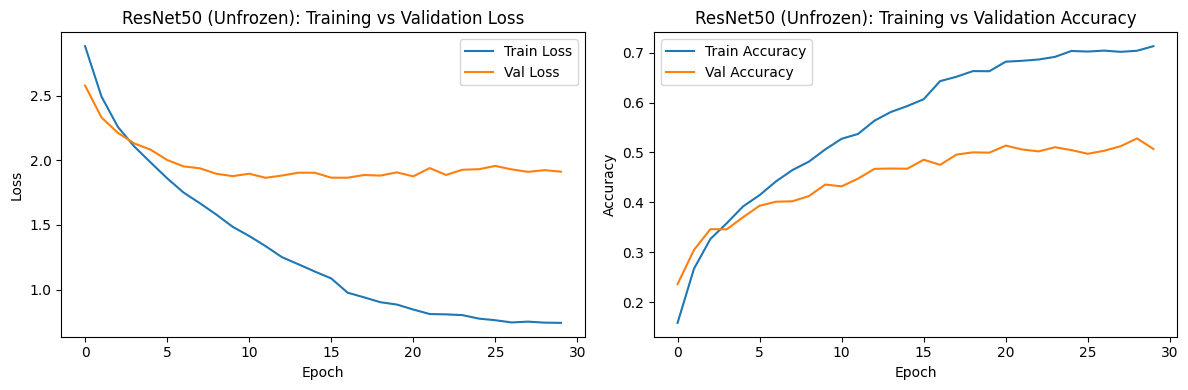

In [22]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('ResNet50 (Unfrozen): Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Val Accuracy')
ax2.set_title('ResNet50 (Unfrozen): Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/resnet50_curves.png')
plt.show()

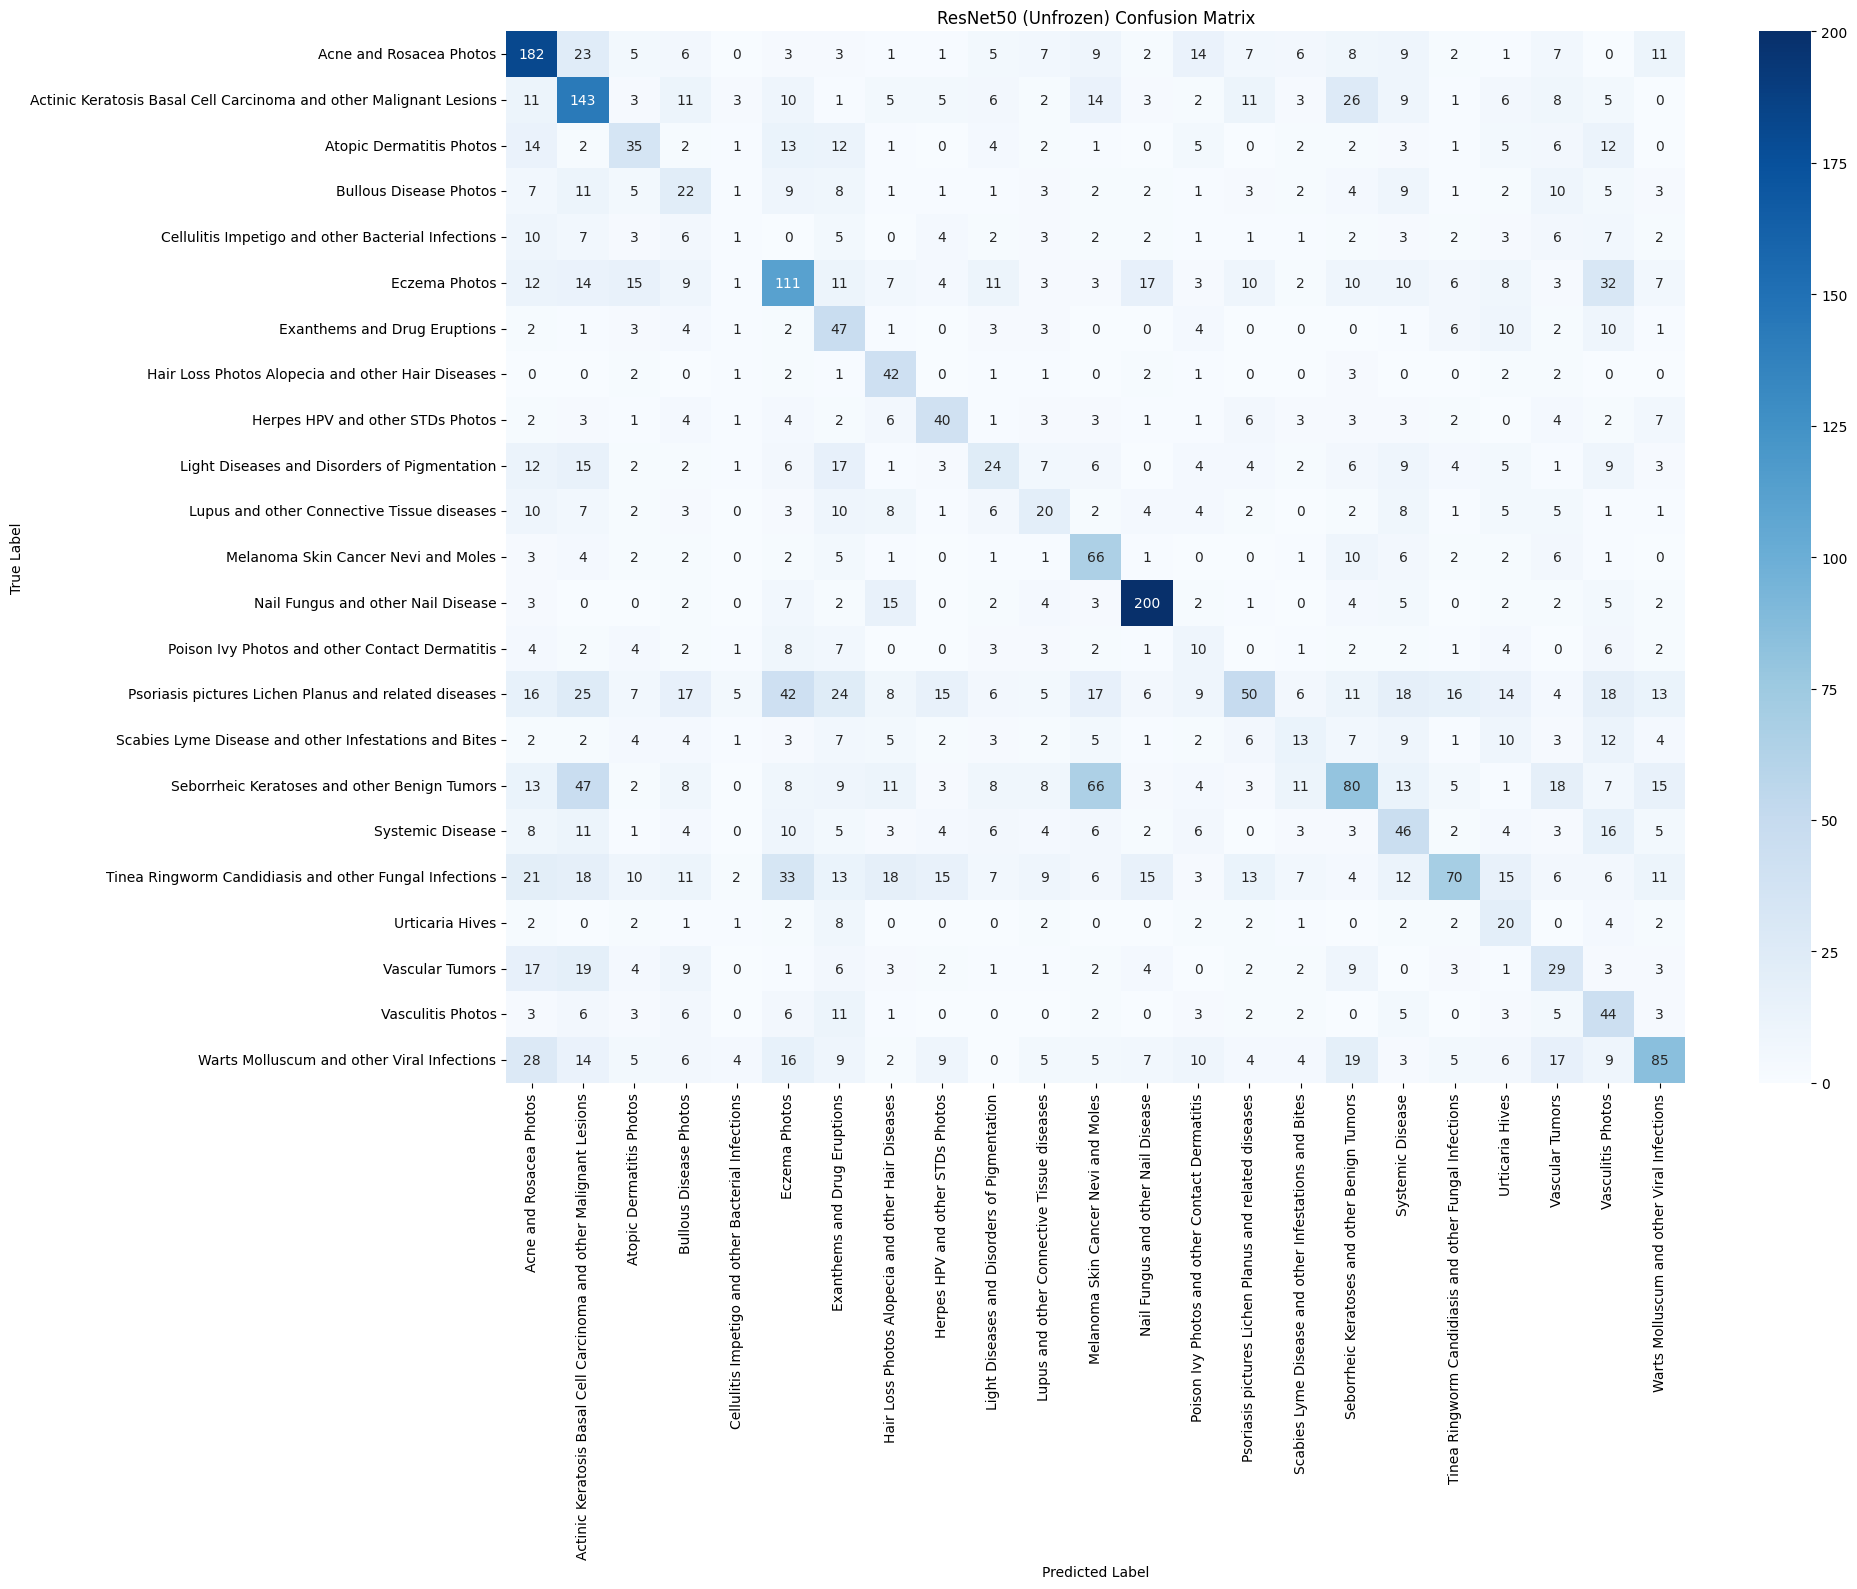

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap='Blues')
plt.title('ResNet50 (Unfrozen) Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/resnet50_confusion.png')
plt.show()

In [25]:
model.load_state_dict(torch.load('/content/best_resnet50_unfrozen.pth'))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== TEST RESULTS ===")
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score  : {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds, average='weighted'):.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Evaluating: 100%|██████████| 126/126 [00:35<00:00,  3.59it/s]


=== TEST RESULTS ===
Accuracy  : 0.5347
F1 Score  : 0.5379
Precision : 0.5583
Recall    : 0.5347

Full Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.75      0.82      0.78       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.63      0.50      0.56       288
                                          Atopic Dermatitis Photos       0.48      0.52      0.50       123
                                            Bullous Disease Photos       0.41      0.48      0.44       113
                Cellulitis Impetigo and other Bacterial Infections       0.23      0.32      0.27        73
                                                     Eczema Photos       0.57      0.40      0.47       309
                                      Exanthems and Drug Eruptions       0.35      0.60      0.44       101
                 Hair L

In [24]:
import shutil
shutil.copy('/content/best_resnet50.pth', '/content/drive/MyDrive/best_resnet50.pth')
print("Saved to Google Drive!")

Saved to Google Drive!
